In [34]:
import geopandas as gpd

In [35]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the spatial data (Point to the .shp file!)
shapefile_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Counties\CA_Counties.shp"
gdf = gpd.read_file(shapefile_path)

# 2. Load your tabular data
df = pd.read_csv("../output/combined_races.csv")
selected_races = ['AD-58', 'CD-13', 'CD-21', 'CD-22', 'CD-40', 'CD-41', 'CD-45', 'CD-47', 'CD-49', 'CD-9', 'SD-19', 'SD-37', 'SD-5']
df = df[df["Race"].isin(selected_races)]
df = pd.DataFrame(df["Jurisdiction"].unique(), columns=["Jurisdiction"])

In [36]:
shapefile_county_col = 'NAME' 

gdf[shapefile_county_col] = gdf[shapefile_county_col].str.strip().str.title()
df['Jurisdiction'] = df['Jurisdiction'].str.strip().str.title()

In [37]:
merged_gdf = gdf.merge(df, left_on=shapefile_county_col, right_on='Jurisdiction', how='left')

In [38]:
gdf["NAME"].unique()

<StringArray>
[         'Sierra',      'Sacramento',   'Santa Barbara',       'Calaveras',
         'Ventura',     'Los Angeles',          'Sonoma',           'Kings',
       'San Diego',          'Placer',   'San Francisco',           'Marin',
        'Mariposa',          'Lassen',            'Napa',          'Shasta',
        'Monterey',         'Trinity',       'Mendocino',            'Inyo',
            'Mono',        'Tuolumne',          'Solano',  'San Bernardino',
    'Contra Costa',          'Alpine',       'El Dorado',            'Yolo',
            'Yuba',      'San Benito',        'Humboldt',       'Riverside',
            'Kern',          'Colusa',       'Del Norte',           'Modoc',
          'Fresno',          'Madera',     'Santa Clara',          'Tehama',
     'San Joaquin',         'Alameda',          'Nevada',           'Butte',
          'Merced',          'Tulare',      'Stanislaus',          'Orange',
        'Imperial',          'Sutter',          'Amador',     

In [39]:
merged_gdf.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,...,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,Shape_Area,geometry,Jurisdiction
0,06,091,00277310,06091,Sierra,Sierra County,06,H1,G4020,NaN,...,NaN,A,2.468695e+09,2.329911e+07,+39.5769252,-120.5219926,375602.758281,4.200450e+09,"POLYGON ((-13431319.751 4821511.426, -13431312...",NaN
1,06,067,00277298,06067,Sacramento,Sacramento County,06,H1,G4020,472,...,NaN,A,2.499984e+09,7.542543e+07,+38.4500161,-121.3404408,406584.174167,4.205516e+09,"POLYGON ((-13490651.476 4680831.603, -13490511...",NaN
2,06,083,00277306,06083,Santa Barbara,Santa Barbara County,06,H1,G4020,NaN,...,NaN,A,7.084063e+09,2.729752e+09,+34.5370572,-120.0399729,891686.747247,1.449841e+10,"MULTIPOLYGON (((-13440081.316 4150394.004, -13...",NaN
3,06,009,01675885,06009,Calaveras,Calaveras County,06,H1,G4020,NaN,...,NaN,A,2.641785e+09,4.384187e+07,+38.1838996,-120.5614415,367005.879680,4.356213e+09,"POLYGON ((-13428575.483 4627725.227, -13428534...",NaN
4,06,111,00277320,06111,Ventura,Ventura County,06,H1,G4020,348,...,NaN,A,4.771988e+09,9.473454e+08,+34.3587415,-119.1331432,527772.242190,8.413293e+09,"MULTIPOLYGON (((-13283668.94 4059436.934, -132...",NaN


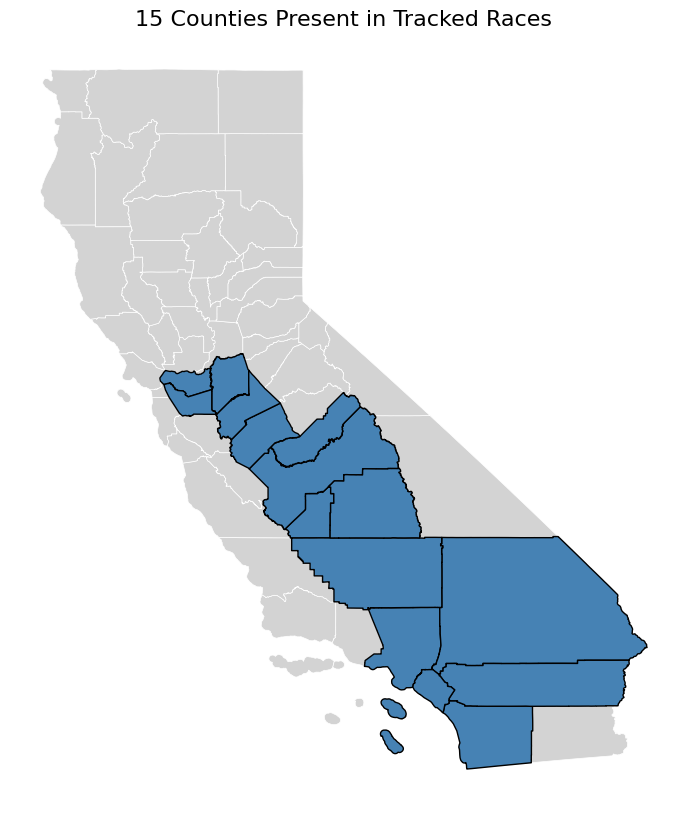

In [40]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

csv_counties = df['Jurisdiction'].unique()

# 4. Filter the GeoDataFrame to only include the counties that are in your CSV
matched_gdf = gdf[gdf[shapefile_county_col].isin(csv_counties)]

# 5. Plot the map
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# First, plot ALL counties in a neutral background color (like light grey)
gdf.plot(
    ax=ax, 
    color='lightgrey', 
    edgecolor='white', 
    linewidth=0.5
)

# Next, plot ONLY the matched counties on top in your chosen single color (e.g., 'steelblue')
matched_gdf.plot(
    ax=ax, 
    color='steelblue',
    edgecolor='black', 
    linewidth=1
)

# Clean up the visual
ax.axis('off')
plt.title('15 Counties Present in Tracked Races', fontsize=16)

plt.show()

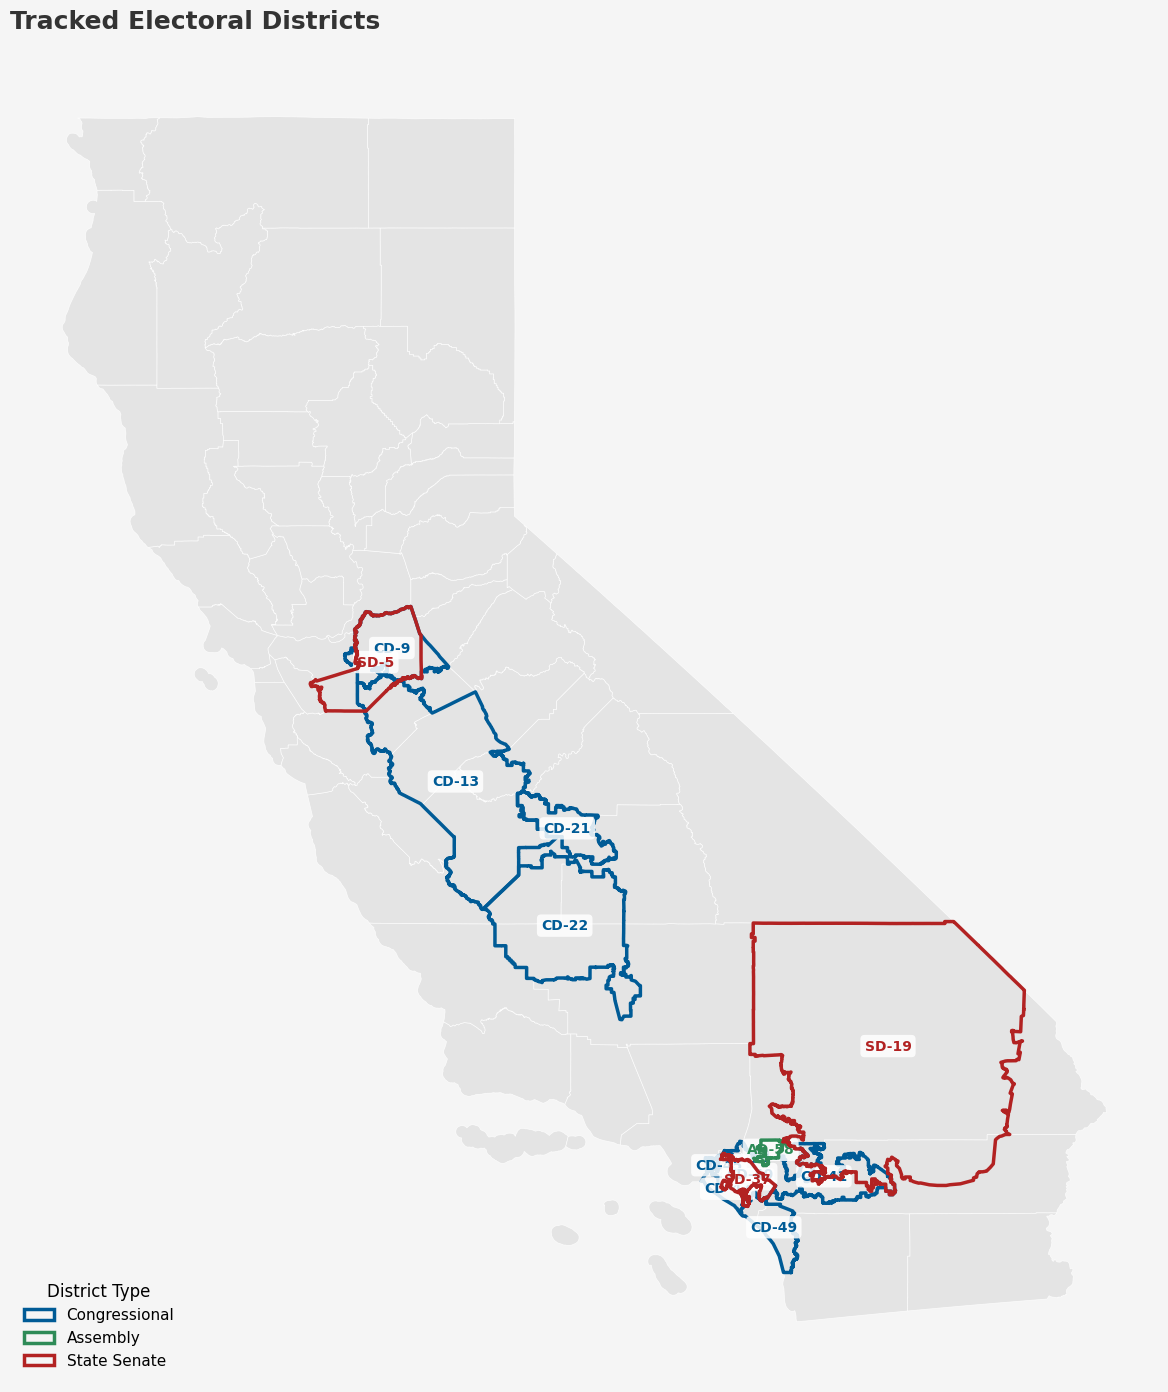

In [47]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Load the CSV data and extract the tracked district numbers
df = pd.read_csv("../output/combined_races.csv")
df = df[df["Race"].isin(selected_races)]

# Extract district numbers, clean them, and convert to strings
# Note: .str.lstrip('0') ensures that '05' from a shapefile matches '5' from your CSV
tracked_cds = df.loc[df['Race'].str.startswith('CD-'), 'Race'].str.replace('CD-', '').astype(str).str.lstrip('0').tolist()
tracked_ads = df.loc[df['Race'].str.startswith('AD-'), 'Race'].str.replace('AD-', '').astype(str).str.lstrip('0').tolist()
tracked_sds = df.loc[df['Race'].str.startswith('SD-'), 'Race'].str.replace('SD-', '').astype(str).str.lstrip('0').tolist()

# 2. Define file paths (using .shp)
counties_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Counties\CA_Counties.shp"
assembly_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Assembly_Districts\CA_State_Assembly_Districts_and_Membership_2024_to_2026.shp"
congress_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Congressional_Districts\Congressional_Districts.shp"
senate_path   = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Senate_Districts\CA_State_Senate_Districts_and_Membership_2025-2030.shp"

# 3. Load the Shapefiles
gdf_counties = gpd.read_file(counties_path)
gdf_assembly = gpd.read_file(assembly_path)
gdf_congress = gpd.read_file(congress_path)
gdf_senate   = gpd.read_file(senate_path)

# 4. ALIGN CRS
target_crs = gdf_counties.crs
gdf_assembly = gdf_assembly.to_crs(target_crs)
gdf_congress = gdf_congress.to_crs(target_crs)
gdf_senate   = gdf_senate.to_crs(target_crs)

# 5. Filter shapefiles using the provided column names
cd_col = 'CD119FP'
ad_col = 'DISTRICT'
sd_col = 'district'

# Clean the shapefile columns the same way (strip leading zeros to ensure a perfect match)
matched_congress = gdf_congress[gdf_congress[cd_col].astype(str).str.lstrip('0').isin(tracked_cds)]
matched_assembly = gdf_assembly[gdf_assembly[ad_col].astype(str).str.lstrip('0').isin(tracked_ads)]
matched_senate   = gdf_senate[gdf_senate[sd_col].astype(str).str.lstrip('0').isin(tracked_sds)]

# 6. Plotting
fig, ax = plt.subplots(1, 1, figsize=(12, 14), facecolor='#F5F5F5') # Soft background color

# Layer 1: Base Map (Counties)
# Muted base map so the district boundaries pop
gdf_counties.plot(ax=ax, color='#E0E0E0', edgecolor='#FFFFFF', linewidth=0.5, alpha=0.8)

# Layer 2: Outlines for Tracked Districts
if not matched_congress.empty:
    matched_congress.plot(ax=ax, facecolor='none', edgecolor='#005B96', linewidth=2.5, zorder=3)

if not matched_assembly.empty:
    matched_assembly.plot(ax=ax, facecolor='none', edgecolor='#2E8B57', linewidth=2.5, zorder=4)

if not matched_senate.empty:
    matched_senate.plot(ax=ax, facecolor='none', edgecolor='#B22222', linewidth=2.5, zorder=5)

# Layer 3: Labels in the middle (Centroid)
def add_labels(gdf, district_type, col_name, color):
    for idx, row in gdf.iterrows():
        centroid = row.geometry.centroid
        dist_num = str(row[col_name]).lstrip('0')
        label_text = f"{district_type}-{dist_num}"
        
        ax.annotate(text=label_text, 
                    xy=(centroid.x, centroid.y), 
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=10,
                    fontweight='600',
                    fontfamily='sans-serif',
                    color=color,
                    bbox=dict(facecolor='#FFFFFF', alpha=0.85, edgecolor='none', pad=2, boxstyle='round,pad=0.3'))

# Apply the labels
add_labels(matched_congress, 'CD', cd_col, '#005B96')
add_labels(matched_assembly, 'AD', ad_col, '#2E8B57')
add_labels(matched_senate, 'SD', sd_col, '#B22222')

# Clean up layout
ax.axis('off')
plt.title('Tracked Electoral Districts', fontsize=18, fontweight='bold', pad=20, loc='left', color='#333333')

# Custom Legend
blue_patch = mpatches.Patch(edgecolor='#005B96', facecolor='none', label='Congressional', linewidth=2.5)
green_patch = mpatches.Patch(edgecolor='#2E8B57', facecolor='none', label='Assembly', linewidth=2.5)
red_patch = mpatches.Patch(edgecolor='#B22222', facecolor='none', label='State Senate', linewidth=2.5)

# Place legend cleanly outside the main map area to avoid clutter
plt.legend(handles=[blue_patch, green_patch, red_patch], 
           loc='lower left', 
           frameon=False,
           fontsize=11,
           title='District Type',
           title_fontsize=12)

plt.tight_layout()
plt.show()

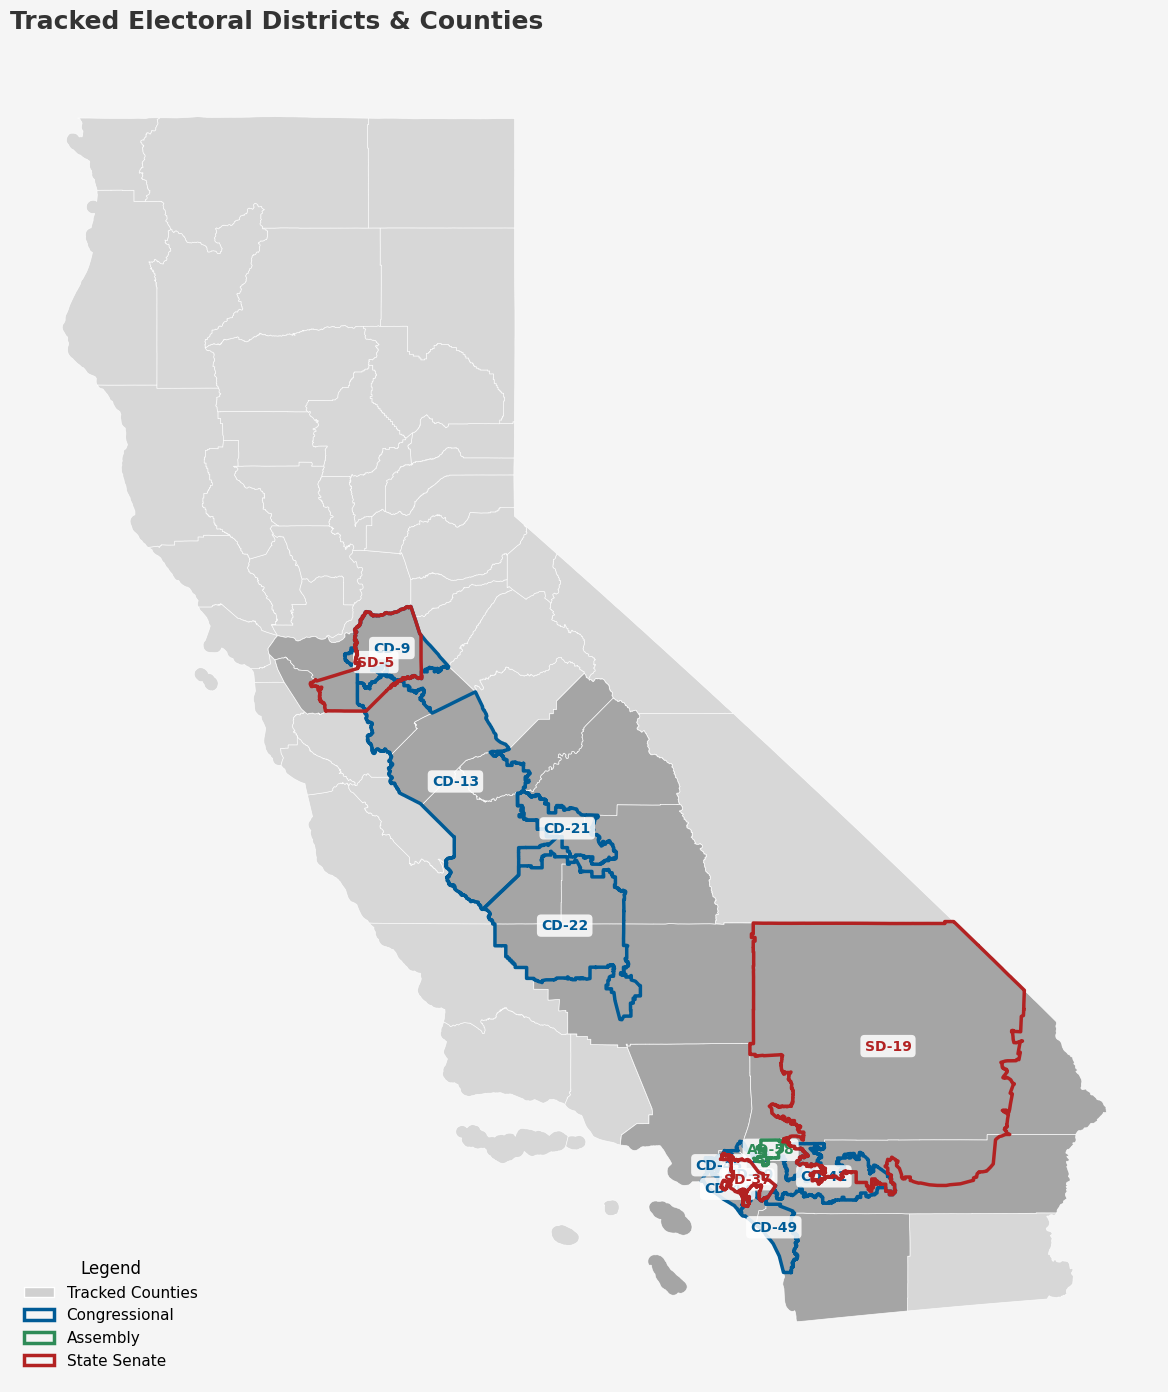

In [50]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Extract district numbers, clean them, and convert to strings
tracked_cds = df.loc[df['Race'].str.startswith('CD-'), 'Race'].str.replace('CD-', '').astype(str).str.lstrip('0').tolist()
tracked_ads = df.loc[df['Race'].str.startswith('AD-'), 'Race'].str.replace('AD-', '').astype(str).str.lstrip('0').tolist()
tracked_sds = df.loc[df['Race'].str.startswith('SD-'), 'Race'].str.replace('SD-', '').astype(str).str.lstrip('0').tolist()

# Extract and clean tracked counties
tracked_counties = df['Jurisdiction'].dropna().str.strip().str.title().unique().tolist()

# 2. Define file paths (using .shp)
counties_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Counties\CA_Counties.shp"
assembly_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Assembly_Districts\CA_State_Assembly_Districts_and_Membership_2024_to_2026.shp"
congress_path = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Congressional_Districts\Congressional_Districts.shp"
senate_path   = r"C:\Users\ricky\OneDrive\Desktop\Stats 305C\realtimeElectionForecasting\CCTP_data\Senate_Districts\CA_State_Senate_Districts_and_Membership_2025-2030.shp"

# 3. Load the Shapefiles
gdf_counties = gpd.read_file(counties_path)
gdf_assembly = gpd.read_file(assembly_path)
gdf_congress = gpd.read_file(congress_path)
gdf_senate   = gpd.read_file(senate_path)

# 4. ALIGN CRS
target_crs = gdf_counties.crs
gdf_assembly = gdf_assembly.to_crs(target_crs)
gdf_congress = gdf_congress.to_crs(target_crs)
gdf_senate   = gdf_senate.to_crs(target_crs)

# 5. Filter shapefiles using the provided column names
cd_col = 'CD119FP'
ad_col = 'DISTRICT'
sd_col = 'district'
county_col = 'NAME' # Change this if your county shapefile uses a different column name for counties

# Match districts
matched_congress = gdf_congress[gdf_congress[cd_col].astype(str).str.lstrip('0').isin(tracked_cds)]
matched_assembly = gdf_assembly[gdf_assembly[ad_col].astype(str).str.lstrip('0').isin(tracked_ads)]
matched_senate   = gdf_senate[gdf_senate[sd_col].astype(str).str.lstrip('0').isin(tracked_sds)]

# Match counties (standardize names first to ensure clean matching)
gdf_counties[county_col] = gdf_counties[county_col].str.strip().str.title()
matched_counties = gdf_counties[gdf_counties[county_col].isin(tracked_counties)]

# 6. Plotting
fig, ax = plt.subplots(1, 1, figsize=(12, 14), facecolor='#F5F5F5') # Soft background color

# Layer 1a: Base Map (All Counties - Very light)
gdf_counties.plot(ax=ax, color='#D0D0D0', edgecolor='#FFFFFF', linewidth=0.5, alpha=0.8)

# Layer 1b: Tracked Counties (Slightly darker shade)
if not matched_counties.empty:
    matched_counties.plot(ax=ax, color='#A0A0A0', edgecolor='#FFFFFF', linewidth=0.5, alpha=0.9, zorder=2)

# Layer 2: Outlines for Tracked Districts
if not matched_congress.empty:
    matched_congress.plot(ax=ax, facecolor='none', edgecolor='#005B96', linewidth=2.5, zorder=3)

if not matched_assembly.empty:
    matched_assembly.plot(ax=ax, facecolor='none', edgecolor='#2E8B57', linewidth=2.5, zorder=4)

if not matched_senate.empty:
    matched_senate.plot(ax=ax, facecolor='none', edgecolor='#B22222', linewidth=2.5, zorder=5)

# Layer 3: Labels in the middle (Centroid)
def add_labels(gdf, district_type, col_name, color):
    for idx, row in gdf.iterrows():
        centroid = row.geometry.centroid
        dist_num = str(row[col_name]).lstrip('0')
        label_text = f"{district_type}-{dist_num}"
        
        ax.annotate(text=label_text, 
                    xy=(centroid.x, centroid.y), 
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=10,
                    fontweight='600',
                    fontfamily='sans-serif',
                    color=color,
                    bbox=dict(facecolor='#FFFFFF', alpha=0.85, edgecolor='none', pad=2, boxstyle='round,pad=0.3'))

# Apply the labels
add_labels(matched_congress, 'CD', cd_col, '#005B96')
add_labels(matched_assembly, 'AD', ad_col, '#2E8B57')
add_labels(matched_senate, 'SD', sd_col, '#B22222')

# Clean up layout
ax.axis('off')
plt.title('Tracked Electoral Districts & Counties', fontsize=18, fontweight='bold', pad=20, loc='left', color='#333333')

# Custom Legend
county_patch = mpatches.Patch(facecolor='#D0D0D0', edgecolor='#FFFFFF', label='Tracked Counties')
blue_patch = mpatches.Patch(edgecolor='#005B96', facecolor='none', label='Congressional', linewidth=2.5)
green_patch = mpatches.Patch(edgecolor='#2E8B57', facecolor='none', label='Assembly', linewidth=2.5)
red_patch = mpatches.Patch(edgecolor='#B22222', facecolor='none', label='State Senate', linewidth=2.5)

# Place legend cleanly outside the main map area to avoid clutter
plt.legend(handles=[county_patch, blue_patch, green_patch, red_patch], 
           loc='lower left', 
           frameon=False,
           fontsize=11,
           title='Legend',
           title_fontsize=12)

plt.tight_layout()
plt.show()